# TP7 — Chest X-Ray Classification avec CNN from scratch


Objectif :
- utiliser le dataset `chest_xray` depuis Google Drive ;
- construire un **CNN from scratch** avec PyTorch ;
- ne pas utiliser VGG16, ResNet ou modèle pré-entraîné ;
- corriger le problème de validation trop petite ;
- améliorer la stabilité de l'entraînement.

Structure attendue du dataset :

```text
/content/drive/MyDrive/TP7+projet/chest_xray
├── train
│   ├── NORMAL
│   └── PNEUMONIA
├── val
│   ├── NORMAL
│   └── PNEUMONIA
└── test
    ├── NORMAL
    └── PNEUMONIA
```

Important :
- Le dossier `val` original est souvent très petit.
- Donc cette version crée une **nouvelle validation stratifiée à partir de train**.
- Le dossier `test` original reste réservé au test final.

In [1]:
# ============================================================
# 1) Montage Google Drive et configuration
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import time
import copy
import shutil
import random
from pathlib import Path

# Chemin exact donné par l'utilisateur
DATASET_DIR_DRIVE = "/content/drive/MyDrive/TP7+projet/chest_xray"

# Pour accélérer l'entraînement sur Colab, on copie le dataset dans /content
COPY_TO_LOCAL = True
LOCAL_DATASET_DIR = "/content/chest_xray"

# Dossier où on sauvegarde les modèles et résultats
PROJECT_DRIVE_DIR = "/content/drive/MyDrive/TP7+projet/chest_xray_results_from_scratch"
MODELS_DIR = os.path.join(PROJECT_DRIVE_DIR, "models")
RESULTS_DIR = os.path.join(PROJECT_DRIVE_DIR, "results")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Hyperparamètres principaux
IMG_SIZE = 160          # 160 est plus rapide que 224 et reste suffisant pour un CNN from scratch
BATCH_SIZE = 32
EPOCHS = 30            # maximum ; EarlyStopping peut arrêter avant
PATIENCE = 7
LR = 3e-4
WEIGHT_DECAY = 1e-4
VAL_RATIO_FROM_TRAIN = 0.20
SEED = 42

print("DATASET_DIR_DRIVE:", DATASET_DIR_DRIVE)
print("PROJECT_DRIVE_DIR:", PROJECT_DRIVE_DIR)

Mounted at /content/drive
DATASET_DIR_DRIVE: /content/drive/MyDrive/TP7+projet/chest_xray
PROJECT_DRIVE_DIR: /content/drive/MyDrive/TP7+projet/chest_xray_results_from_scratch


In [2]:
# ============================================================
# 2) Reproductibilité + device GPU/CPU
# ============================================================

import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Pour des résultats plus reproductibles
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device utilisé: cuda
GPU: Tesla T4


In [ ]:
# ============================================================
# 3) Copier le dataset vers /content pour accélérer Colab
# ============================================================

def verify_chest_xray_structure(dataset_dir):
    expected = [
        os.path.join(dataset_dir, "train", "NORMAL"),
        os.path.join(dataset_dir, "train", "PNEUMONIA"),
        os.path.join(dataset_dir, "val", "NORMAL"),
        os.path.join(dataset_dir, "val", "PNEUMONIA"),
        os.path.join(dataset_dir, "test", "NORMAL"),
        os.path.join(dataset_dir, "test", "PNEUMONIA"),
    ]
    missing = [p for p in expected if not os.path.isdir(p)]
    if missing:
        raise FileNotFoundError("Dossiers manquants:\n" + "\n".join(missing))
    print(" Structure du dataset correcte.")

verify_chest_xray_structure(DATASET_DIR_DRIVE)

if COPY_TO_LOCAL:
    if os.path.exists(LOCAL_DATASET_DIR):
        print(" Dataset déjà copié dans /content.")
    else:
        print("Copie du dataset depuis Drive vers /content ...")
        shutil.copytree(DATASET_DIR_DRIVE, LOCAL_DATASET_DIR)
        print(" Copie terminée.")
    DATASET_DIR = LOCAL_DATASET_DIR
else:
    DATASET_DIR = DATASET_DIR_DRIVE

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
ORIGINAL_VAL_DIR = os.path.join(DATASET_DIR, "val")
TEST_DIR = os.path.join(DATASET_DIR, "test")

print("TRAIN_DIR:", TRAIN_DIR)
print("ORIGINAL_VAL_DIR:", ORIGINAL_VAL_DIR)
print("TEST_DIR:", TEST_DIR)

✅ Structure du dataset correcte.
⏳ Copie du dataset depuis Drive vers /content ...
✅ Copie terminée.
TRAIN_DIR: /content/chest_xray/train
ORIGINAL_VAL_DIR: /content/chest_xray/val
TEST_DIR: /content/chest_xray/test


In [4]:
# ============================================================
# 4) Imports PyTorch / torchvision / sklearn
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from PIL import Image

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

plt.style.use("ggplot")

In [5]:
# ============================================================
# 5) Lecture du dataset et séparation train/validation
# ============================================================

# On lit le dossier train pour récupérer les chemins et les labels
base_train_dataset = datasets.ImageFolder(TRAIN_DIR)

classes = base_train_dataset.classes
class_to_idx = base_train_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

print("Classes:", classes)
print("class_to_idx:", class_to_idx)

train_samples_all = base_train_dataset.samples
labels_all = [label for _, label in train_samples_all]

# Split stratifié : chaque classe garde les mêmes proportions dans train et validation
train_samples, val_samples = train_test_split(
    train_samples_all,
    test_size=VAL_RATIO_FROM_TRAIN,
    random_state=SEED,
    stratify=labels_all
)

print("Nombre total train original:", len(train_samples_all))
print("Nouveau train:", len(train_samples))
print("Nouvelle validation:", len(val_samples))

def count_by_class(samples, classes):
    counts = {c: 0 for c in classes}
    for _, label in samples:
        counts[classes[label]] += 1
    return counts

print("\nDistribution nouveau train:")
print(count_by_class(train_samples, classes))

print("\nDistribution nouvelle validation:")
print(count_by_class(val_samples, classes))

# On garde le dossier test original pour l'évaluation finale
test_dataset_probe = datasets.ImageFolder(TEST_DIR)
print("\nTest original:", len(test_dataset_probe), "images")
print("Distribution test:", count_by_class(test_dataset_probe.samples, test_dataset_probe.classes))

# Le dossier val original est gardé uniquement pour information
original_val_probe = datasets.ImageFolder(ORIGINAL_VAL_DIR)
print("\nVal original:", len(original_val_probe), "images")
print("Distribution val original:", count_by_class(original_val_probe.samples, original_val_probe.classes))

Classes: ['NORMAL', 'PNEUMONIA']
class_to_idx: {'NORMAL': 0, 'PNEUMONIA': 1}
Nombre total train original: 5216
Nouveau train: 4172
Nouvelle validation: 1044

Distribution nouveau train:
{'NORMAL': 1073, 'PNEUMONIA': 3099}

Distribution nouvelle validation:
{'NORMAL': 268, 'PNEUMONIA': 776}

Test original: 624 images
Distribution test: {'NORMAL': 234, 'PNEUMONIA': 390}

Val original: 16 images
Distribution val original: {'NORMAL': 8, 'PNEUMONIA': 8}


In [6]:
# ============================================================
# 6) Dataset personnalisé basé sur une liste de chemins
# ============================================================

class XRaySamplesDataset(Dataset):
    def __init__(self, samples, classes, class_to_idx, transform=None):
        self.samples = samples
        self.classes = classes
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        path, label = self.samples[index]
        image = Image.open(path).convert("L")  # grayscale : 1 canal
        if self.transform is not None:
            image = self.transform(image)
        return image, label

In [7]:
# ============================================================
# 7) Calcul de la moyenne et de l'écart-type du train
# ============================================================

# On calcule mean/std sur le nouveau train pour normaliser correctement les radios.
# Cela améliore généralement la stabilité par rapport à Normalize(0.5, 0.5).

base_transform_for_stats = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

stats_dataset = XRaySamplesDataset(
    train_samples,
    classes=classes,
    class_to_idx=class_to_idx,
    transform=base_transform_for_stats
)

stats_loader = DataLoader(
    stats_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

def compute_mean_std(loader):
    mean = 0.0
    std = 0.0
    n_images = 0

    for images, _ in loader:
        batch_size = images.size(0)
        images = images.view(batch_size, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        n_images += batch_size

    mean /= n_images
    std /= n_images
    return mean.tolist(), std.tolist()

mean, std = compute_mean_std(stats_loader)
print("Mean train:", mean)
print("Std train :", std)

Mean train: [0.4823515713214874]
Std train : [0.22082796692848206]


In [8]:
# ============================================================
# 8) Transformations images
# ============================================================

# Augmentation modérée adaptée aux radios.
# On évite les transformations trop fortes pour ne pas déformer le contenu médical.

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(
        degrees=7,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

train_dataset = XRaySamplesDataset(train_samples, classes, class_to_idx, transform=train_transform)
val_dataset = XRaySamplesDataset(val_samples, classes, class_to_idx, transform=eval_transform)

# Train eval sans augmentation pour mesurer proprement l'accuracy train
train_eval_dataset = XRaySamplesDataset(train_samples, classes, class_to_idx, transform=eval_transform)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=eval_transform
)

original_val_dataset = datasets.ImageFolder(
    ORIGINAL_VAL_DIR,
    transform=eval_transform
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
train_eval_loader = DataLoader(train_eval_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
original_val_loader = DataLoader(original_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 131
Validation batches: 33
Test batches: 20


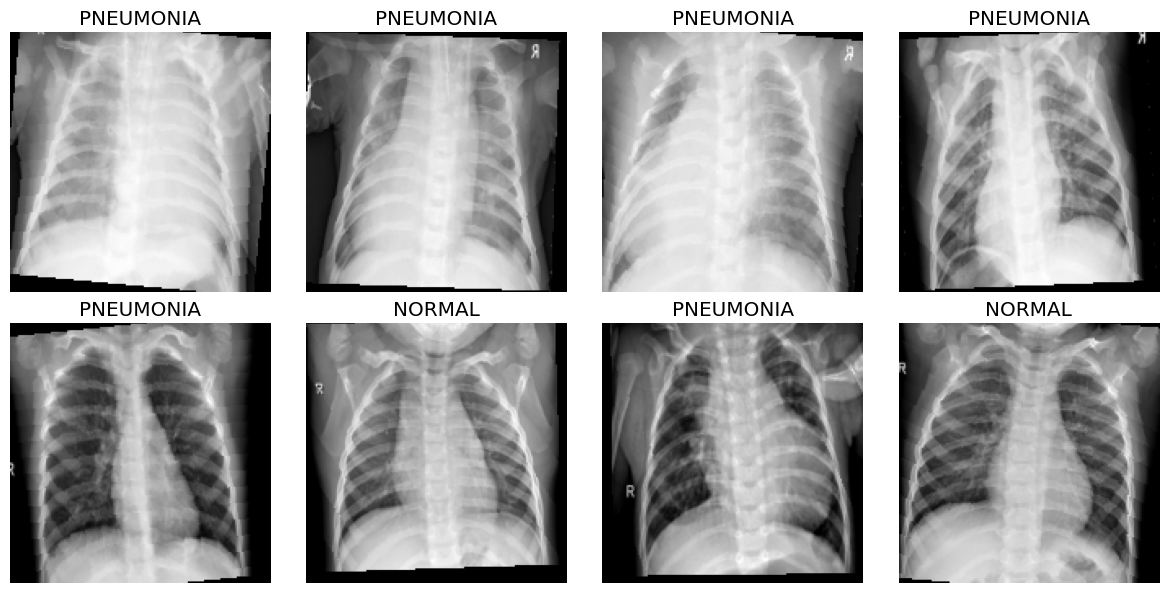

In [9]:
# ============================================================
# 9) Visualiser quelques images du train
# ============================================================

def unnormalize(img_tensor, mean, std):
    img = img_tensor.clone()
    img = img * std[0] + mean[0]
    return img.clamp(0, 1)

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    img = unnormalize(images[i].cpu(), mean, std).squeeze(0)
    plt.imshow(img, cmap="gray")
    plt.title(classes[labels[i].item()])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# 10) Poids de classes pour gérer le déséquilibre
# ============================================================

train_labels = np.array([label for _, label in train_samples])

class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

print("Class weights:", {classes[i]: float(class_weights_np[i]) for i in range(len(classes))})

Class weights: {'NORMAL': 1.9440820130475303, 'PNEUMONIA': 0.6731203614069055}


In [11]:
# ============================================================
# 11) CNN from scratch amélioré
# ============================================================

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(dropout)
        )

    def forward(self, x):
        return self.block(x)


class ChestXRayCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.features = nn.Sequential(
            ConvBlock(1, 32, dropout=0.05),    # 160 -> 80
            ConvBlock(32, 64, dropout=0.10),   # 80 -> 40
            ConvBlock(64, 128, dropout=0.15),  # 40 -> 20
            ConvBlock(128, 256, dropout=0.20), # 20 -> 10
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.40),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


model = ChestXRayCNN(num_classes=len(classes)).to(device)

print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")

ChestXRayCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout2d(p=0.05, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=

In [12]:
# ============================================================
# 12) Fonctions train / evaluate
# ============================================================

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

use_amp = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


def train_one_epoch(model, loader, criterion, optimizer, device, scaler=None):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)

/tmp/ipykernel_785/805159507.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


In [13]:
# ============================================================
# 13) Entraînement avec EarlyStopping
# ============================================================

best_model_path = os.path.join(MODELS_DIR, "best_cnn_from_scratch.pt")

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": []
}

best_val_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device, scaler=scaler
    )

    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    print(
        f"Epoch [{epoch}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | LR: {current_lr:.6f}"
    )

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save({
            "model_state_dict": model.state_dict(),
            "classes": classes,
            "class_to_idx": class_to_idx,
            "mean": mean,
            "std": std,
            "img_size": IMG_SIZE,
            "history": history,
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
        }, best_model_path)

        print("✅ Nouveau meilleur modèle sauvegardé.")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print("⏹️ Early stopping activé.")
        break

execution_time = time.time() - start_time

minutes = int(execution_time // 60)
seconds = int(execution_time % 60)
print(f"\nTemps total d'entraînement : {minutes} min {seconds} s")
print(f"Meilleure epoch : {best_epoch}")
print(f"Meilleure val loss : {best_val_loss:.4f}")

/tmp/ipykernel_785/805159507.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch [1/30] Train Loss: 0.3981 | Train Acc: 0.8154 | Val Loss: 0.2991 | Val Acc: 0.8554 | LR: 0.000300
✅ Nouveau meilleur modèle sauvegardé.
Epoch [2/30] Train Loss: 0.3025 | Train Acc: 0.8691 | Val Loss: 0.2228 | Val Acc: 0.8640 | LR: 0.000300
✅ Nouveau meilleur modèle sauvegardé.
Epoch [3/30] Train Loss: 0.2559 | Train Acc: 0.8965 | Val Loss: 0.2050 | Val Acc: 0.8841 | LR: 0.000300
✅ Nouveau meilleur modèle sauvegardé.
Epoch [4/30] Train Loss: 0.2282 | Train Acc: 0.9065 | Val Loss: 0.1380 | Val Acc: 0.9272 | LR: 0.000300
✅ Nouveau meilleur modèle sauvegardé.
Epoch [5/30] Train Loss: 0.2158 | Train Acc: 0.9096 | Val Loss: 0.1335 | Val Acc: 0.9387 | LR: 0.000300
✅ Nouveau meilleur modèle sauvegardé.
Epoch [6/30] Train Loss: 0.1978 | Train Acc: 0.9195 | Val Loss: 0.1358 | Val Acc: 0.9349 | LR: 0.000300
Epoch [7/30] Train Loss: 0.1718 | Train Acc: 0.9314 | Val Loss: 0.2300 | Val Acc: 0.8707 | LR: 0.000300
Epoch [8/30] Train Loss: 0.1642 | Train Acc: 0.9346 | Val Loss: 0.1583 | Val Acc: 

In [15]:
# ============================================================
# 14) Charger le meilleur modèle et évaluer globalement
# ============================================================

checkpoint = torch.load(best_model_path, map_location=device)

best_model = ChestXRayCNN(num_classes=len(classes)).to(device)
best_model.load_state_dict(checkpoint["model_state_dict"])

# --- Fix Start ---
# The error occurs because test_dataset and original_val_dataset (created using ImageFolder)
# load images as 3-channel RGB by default, while the model expects 1-channel grayscale input.
# The original eval_transform does not include a grayscale conversion for ImageFolder.
# We create a new eval_transform_fixed to explicitly convert to grayscale.
eval_transform_fixed = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1), # Explicitly convert to grayscale
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Recreate test_dataset and original_val_dataset with the fixed transform
test_dataset_fixed = datasets.ImageFolder(
    TEST_DIR,
    transform=eval_transform_fixed
)
original_val_dataset_fixed = datasets.ImageFolder(
    ORIGINAL_VAL_DIR,
    transform=eval_transform_fixed
)

# Recreate their respective loaders
test_loader_fixed = DataLoader(test_dataset_fixed, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
original_val_loader_fixed = DataLoader(original_val_dataset_fixed, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
# --- Fix End ---


train_loss_eval, train_acc_eval, train_preds, train_true = evaluate(best_model, train_eval_loader, criterion, device)
val_loss_eval, val_acc_eval, val_preds, val_true = evaluate(best_model, val_loader, criterion, device)
test_loss_eval, test_acc_eval, test_preds, test_true = evaluate(best_model, test_loader_fixed, criterion, device)
orig_val_loss, orig_val_acc, orig_val_preds, orig_val_true = evaluate(best_model, original_val_loader_fixed, criterion, device)

results_df = pd.DataFrame({
    "Jeu": ["Train sans augmentation", "Validation créée depuis train", "Validation originale", "Test final"],
    "Loss": [train_loss_eval, val_loss_eval, orig_val_loss, test_loss_eval],
    "Accuracy": [train_acc_eval, val_acc_eval, orig_val_acc, test_acc_eval]
})

display(results_df)

results_csv = os.path.join(RESULTS_DIR, "global_results_cnn_from_scratch.csv")
results_df.to_csv(results_csv, index=False)

print("Résultats sauvegardés dans:", results_csv)

,Jeu,Loss,Accuracy
0,Train sans augmentation,0.065684,0.968840
1,Validation créée depuis train,0.068821,0.965517
2,Validation originale,0.374444,0.812500
3,Test final,0.494735,0.873397


Résultats sauvegardés dans: /content/drive/MyDrive/TP7+projet/chest_xray_results_from_scratch/results/global_results_cnn_from_scratch.csv


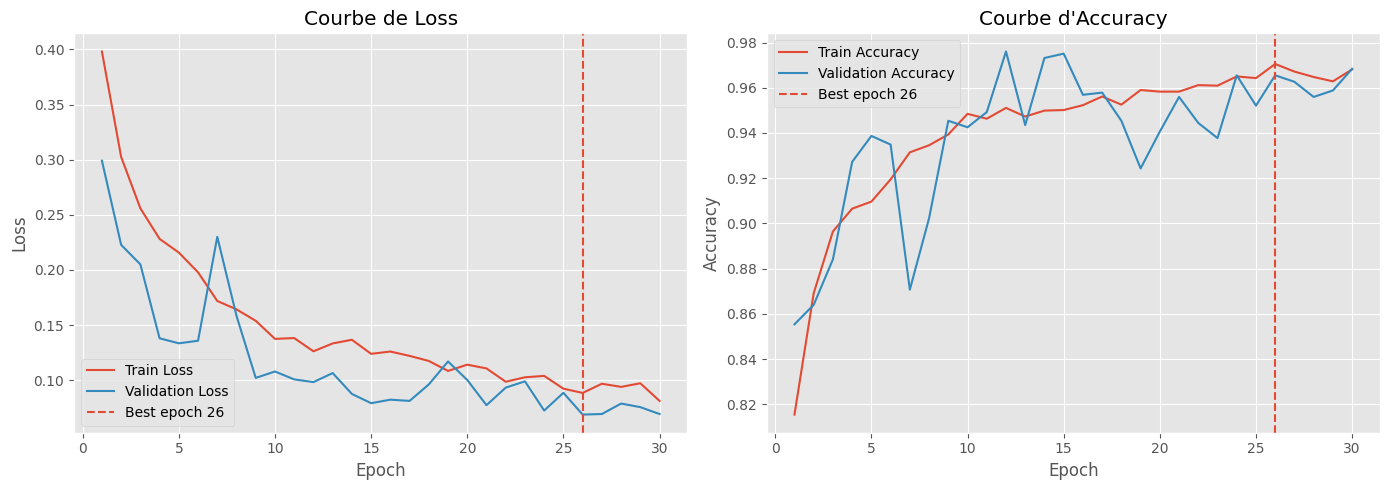

In [16]:
# ============================================================
# 15) Courbes loss / accuracy
# ============================================================

epochs_ran = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_ran, history["train_loss"], label="Train Loss")
plt.plot(epochs_ran, history["val_loss"], label="Validation Loss")
plt.axvline(best_epoch, linestyle="--", label=f"Best epoch {best_epoch}")
plt.title("Courbe de Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_ran, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_ran, history["val_acc"], label="Validation Accuracy")
plt.axvline(best_epoch, linestyle="--", label=f"Best epoch {best_epoch}")
plt.title("Courbe d'Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

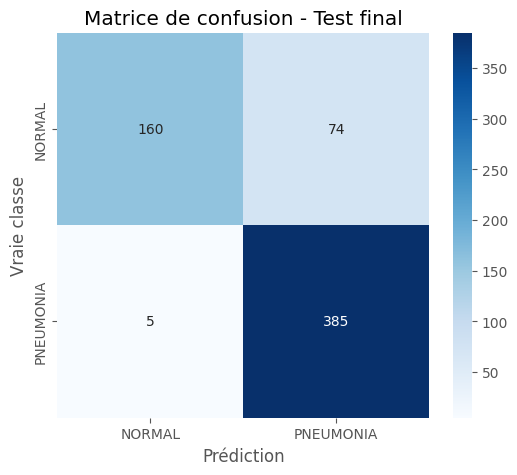

Classification report - Test final:
              precision    recall  f1-score   support

      NORMAL       0.97      0.68      0.80       234
   PNEUMONIA       0.84      0.99      0.91       390

    accuracy                           0.87       624
   macro avg       0.90      0.84      0.85       624
weighted avg       0.89      0.87      0.87       624



In [17]:
# ============================================================
# 16) Matrice de confusion et rapport de classification sur test
# ============================================================

cm = confusion_matrix(test_true, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)
plt.xlabel("Prédiction")
plt.ylabel("Vraie classe")
plt.title("Matrice de confusion - Test final")
plt.show()

print("Classification report - Test final:")
print(classification_report(test_true, test_preds, target_names=classes, zero_division=0))

Nombre d'erreurs sur test : 79 / 624


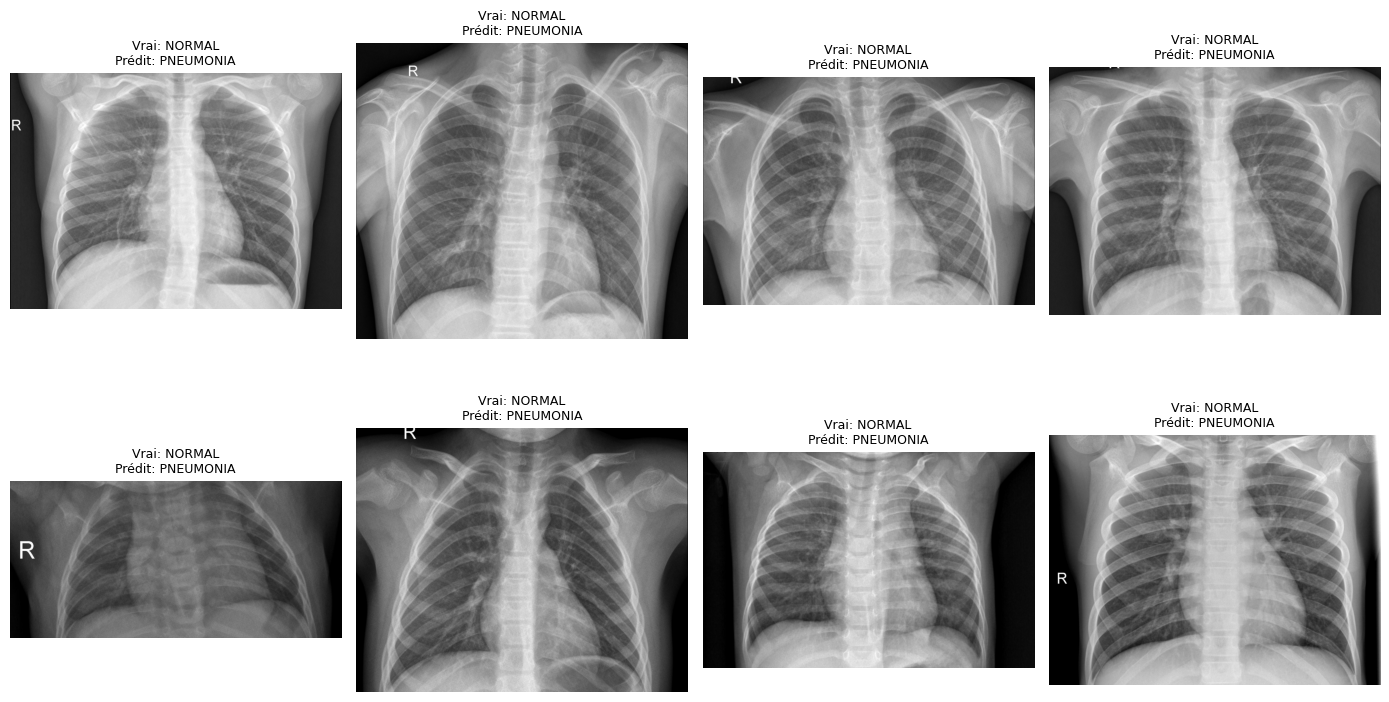

In [18]:
# ============================================================
# 17) Analyse des erreurs sur test
# ============================================================

def show_misclassified_examples(dataset, true_labels, pred_labels, classes, max_images=8):
    wrong_indices = np.where(true_labels != pred_labels)[0]

    print(f"Nombre d'erreurs sur test : {len(wrong_indices)} / {len(true_labels)}")

    if len(wrong_indices) == 0:
        print("Aucune erreur à afficher.")
        return

    plt.figure(figsize=(14, 8))

    for i, idx in enumerate(wrong_indices[:max_images]):
        img_path, true_label = dataset.samples[idx]
        pred_label = pred_labels[idx]

        img = Image.open(img_path).convert("L")

        plt.subplot(2, 4, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"Vrai: {classes[true_label]}\nPrédit: {classes[pred_label]}", fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_misclassified_examples(test_dataset, test_true, test_preds, classes, max_images=8)

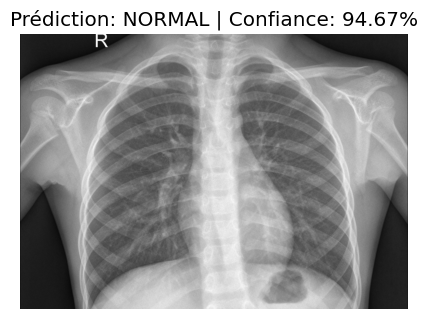

Vraie classe : NORMAL
Classe prédite: NORMAL
Confiance: 0.9466877579689026


In [19]:
# ============================================================
# 18) Prédiction sur une image seule
# ============================================================

def predict_single_image(model, image_path, transform, classes, device):
    model.eval()

    img = Image.open(image_path).convert("L")
    x = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        pred_idx = probs.argmax(dim=1).item()
        confidence = probs[0, pred_idx].item()

    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(f"Prédiction: {classes[pred_idx]} | Confiance: {confidence:.2%}")
    plt.show()

    return classes[pred_idx], confidence

# Exemple : prédire une image du test
sample_image_path, sample_label = test_dataset.samples[0]
pred_label, confidence = predict_single_image(best_model, sample_image_path, eval_transform, classes, device)

print("Vraie classe :", classes[sample_label])
print("Classe prédite:", pred_label)
print("Confiance:", confidence)

In [20]:
# ============================================================
# 19) Sauvegarde d'un résumé final
# ============================================================

summary_path = os.path.join(RESULTS_DIR, "summary_cnn_from_scratch.txt")

with open(summary_path, "w", encoding="utf-8") as f:
    f.write("Résumé CNN from scratch - Chest X-Ray\n")
    f.write("=" * 50 + "\n")
    f.write(f"Dataset: {DATASET_DIR_DRIVE}\n")
    f.write(f"IMG_SIZE: {IMG_SIZE}\n")
    f.write(f"BATCH_SIZE: {BATCH_SIZE}\n")
    f.write(f"EPOCHS max: {EPOCHS}\n")
    f.write(f"Best epoch: {best_epoch}\n")
    f.write(f"Best val loss: {best_val_loss:.4f}\n")
    f.write(f"Temps total: {minutes} min {seconds} s\n")
    f.write("\nRésultats globaux:\n")
    f.write(results_df.to_string(index=False))
    f.write("\n\nRapport test:\n")
    f.write(classification_report(test_true, test_preds, target_names=classes, zero_division=0))

print("Résumé sauvegardé dans:", summary_path)
print("Modèle sauvegardé dans:", best_model_path)

Résumé sauvegardé dans: /content/drive/MyDrive/TP7+projet/chest_xray_results_from_scratch/results/summary_cnn_from_scratch.txt
Modèle sauvegardé dans: /content/drive/MyDrive/TP7+projet/chest_xray_results_from_scratch/models/best_cnn_from_scratch.pt
